In [ ]:
!git clone https://github.com/cho-colette/Pelagia1.git

fatal: destination path 'Pelagia1' already exists and is not an empty directory.


In [ ]:
%cd /content/Pelagia1
!ls

/content/Pelagia1
data  figures  notebooks  README.md  requirements.txt  results	src


In [ ]:
!pip install -r requirements.txt

In [ ]:
import sys
import os

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(sys.path[0])

/content/Pelagia1/src


In [ ]:
from utils import SignalConfig
from generate_signals import generate_dataset
from extract_features import build_feature_table
from train_classifier import train_classifier
from train_anomaly_model import train_anomaly_model
from streaming_update import run_streaming_update_demo
from plot_branches import plot_decision_tree_figure, plot_confusion_matrix_heatmap

In [ ]:
config = SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)
config

SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)

In [ ]:
print("1. Generating synthetic signals...")
generate_dataset(config=config, samples_per_state=12)

1. Generating synthetic signals...


,time_s,petal_1,petal_2,petal_3,voltage_v,current_a,power_w,energy_j,temperature_c,fold_state,state_id,state_label,case_id
0,0.0,0.009429,0.042330,-0.052062,10.211764,1.076476,10.992715,1.099272,20.562371,0.0,0,normal_harvesting,state_0_sample_000
1,0.1,0.035531,0.052066,-0.053330,10.084936,1.210248,12.205271,2.319799,20.718594,0.0,0,normal_harvesting,state_0_sample_000
2,0.2,0.092859,0.100234,-0.011027,10.606972,1.149566,12.193409,3.539140,20.700546,0.0,0,normal_harvesting,state_0_sample_000
3,0.3,0.123780,0.122659,0.044195,10.394243,1.216094,12.640380,4.803178,20.578021,0.0,0,normal_harvesting,state_0_sample_000
4,0.4,0.142810,0.140046,0.100083,10.356292,1.281293,13.269442,6.130122,20.498533,0.0,0,normal_harvesting,state_0_sample_000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57595,119.5,-0.062167,0.002231,-0.038453,7.212349,0.630218,4.545355,573.229850,23.446934,1.0,3,protective_mode,state_3_sample_011
57596,119.6,-0.058267,0.016913,-0.032748,7.501738,0.473992,3.555762,573.585426,23.779553,1.0,3,protective_mode,state_3_sample_011
57597,119.7,-0.074514,-0.023710,-0.049520,7.405480,0.611537,4.528723,574.038298,23.645223,1.0,3,protective_mode,state_3_sample_011
57598,119.8,-0.060482,0.005795,-0.042847,7.832111,0.616614,4.829389,574.521237,23.590908,1.0,3,protective_mode,state_3_sample_011


In [ ]:
print("2. Extracting features...")
build_feature_table(sample_rate_hz=config.sample_rate_hz)

2. Extracting features...


,case_id,state_id,state_label,amp_petal_1,amp_petal_2,amp_petal_3,mean_petal_1,mean_petal_2,mean_petal_3,std_petal_1,...,max_power_w,mean_dpower,max_abs_dpower,rolling_power_mean_final,rolling_power_std_final,mean_temperature_c,max_temperature_c,mean_dtemp,energy_final_j,fold_state_final
0,state_0_sample_000,0,normal_harvesting,0.265240,0.248275,0.266663,0.015991,-0.004484,0.006199,0.137349,...,18.220955,0.029952,28.830700,13.621520,1.226602,20.958468,21.785827,0.010743,1620.997000,0.0
1,state_0_sample_001,0,normal_harvesting,0.270572,0.267575,0.290659,0.002309,0.004058,0.005495,0.137205,...,18.679017,0.047900,26.667541,15.047591,1.361064,21.658262,22.451357,0.008824,1768.818643,0.0
2,state_0_sample_002,0,normal_harvesting,0.299251,0.298090,0.299572,0.005972,0.003990,-0.006625,0.150760,...,19.629498,0.003771,26.140203,14.009174,1.772419,21.757725,22.549592,0.012509,1733.770582,0.0
3,state_0_sample_003,0,normal_harvesting,0.252505,0.241803,0.272039,0.016573,0.003784,0.007045,0.125953,...,17.809751,0.046560,20.900622,14.383642,1.115314,21.236764,22.096424,0.005860,1621.722749,0.0
4,state_0_sample_004,0,normal_harvesting,0.235345,0.230112,0.245595,0.000039,0.006169,0.005884,0.125614,...,17.850591,0.047815,27.033392,13.659335,1.431119,21.260169,21.939424,0.006210,1663.393894,0.0
5,state_0_sample_005,0,normal_harvesting,0.245434,0.244840,0.249082,-0.003492,-0.005765,0.001083,0.124360,...,19.514997,0.005402,21.469025,15.114321,1.178384,21.692005,22.556868,0.010774,1782.373753,0.0
6,state_0_sample_006,0,normal_harvesting,0.252977,0.257529,0.263262,0.005764,0.009063,0.006632,0.128555,...,17.805874,0.049266,27.881870,13.760604,1.271277,21.997301,23.051574,0.013646,1627.970881,0.0
7,state_0_sample_007,0,normal_harvesting,0.274904,0.253704,0.284634,0.018420,-0.000659,-0.001548,0.141002,...,18.722426,0.015385,23.653035,14.023031,1.401993,21.195924,21.990886,0.007118,1675.765258,0.0
8,state_0_sample_008,0,normal_harvesting,0.282918,0.259296,0.295108,0.000822,0.007862,0.002288,0.139758,...,18.533216,0.011385,25.400666,14.016390,1.320057,21.748308,22.581129,0.006913,1700.985910,0.0
9,state_0_sample_009,0,normal_harvesting,0.241205,0.233893,0.247561,0.003496,0.007255,0.013250,0.125729,...,18.428952,0.007881,24.716060,13.653153,1.271661,21.503743,22.317434,0.006633,1643.269575,0.0


In [ ]:
print("3. Training classifier...")
classifier_outputs = train_classifier()
print(classifier_outputs["metrics"])

3. Training classifier...
{'accuracy': 0.9166666666666666, 'n_train': 36, 'n_test': 12, 'n_features': 25, 'classes': ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']}


In [ ]:
print("4. Training anomaly model...")
anomaly_outputs = train_anomaly_model()
print(anomaly_outputs)

4. Training anomaly model...
{'model': IsolationForest(contamination=0.08, n_estimators=300, random_state=42), 'scaler': StandardScaler(), 'results':                case_id         state_label  anomaly_score  anomaly_flag  \
0   state_0_sample_000   normal_harvesting       0.013364             1   
1   state_0_sample_001   normal_harvesting       0.032960             1   
2   state_0_sample_002   normal_harvesting      -0.068027            -1   
3   state_0_sample_003   normal_harvesting       0.045464             1   
4   state_0_sample_004   normal_harvesting       0.026408             1   
5   state_0_sample_005   normal_harvesting       0.036605             1   
6   state_0_sample_006   normal_harvesting       0.009276             1   
7   state_0_sample_007   normal_harvesting       0.043215             1   
8   state_0_sample_008   normal_harvesting       0.070528             1   
9   state_0_sample_009   normal_harvesting       0.036633             1   
10  state_0_sample_010   

In [ ]:
print("5. Running streaming update demo...")
stream_outputs = run_streaming_update_demo()
print(stream_outputs)

5. Running streaming update demo...
{'model': SGDClassifier(loss='log_loss', max_iter=1, random_state=42, tol=None), 'metrics_df':    samples_seen  batch_end_index  running_accuracy
0             8                8          0.375000
1            16               16          0.312500
2            24               24          0.333333
3            32               32          0.406250
4            40               40          0.275000
5            48               48          0.250000}


In [ ]:
print("6. Plotting figures...")
plot_decision_tree_figure()
plot_confusion_matrix_heatmap()

6. Plotting figures...


PosixPath('figures/pelagia_confusion_matrix.png')

In [ ]:
!find /content/Pelagia1/results -maxdepth 3 -type f
!find /content/Pelagia1/figures -maxdepth 3 -type f

/content/Pelagia1/results/streaming/streaming_metrics.csv
/content/Pelagia1/results/.gitkeep
/content/Pelagia1/results/pelagia_features.csv
/content/Pelagia1/results/models/pelagia_tree_rules.txt
/content/Pelagia1/results/models/anomaly_results.csv
/content/Pelagia1/results/models/anomaly_summary.csv
/content/Pelagia1/results/models/classifier_metrics.csv
/content/Pelagia1/results/models/pelagia_decision_tree.joblib
/content/Pelagia1/results/models/pelagia_anomaly_scaler.joblib
/content/Pelagia1/results/models/confusion_matrix.csv
/content/Pelagia1/results/models/test_predictions.csv
/content/Pelagia1/results/models/pelagia_isolation_forest.joblib
/content/Pelagia1/results/models/classification_report.csv
/content/Pelagia1/results/models/top_anomalous_cases.csv
/content/Pelagia1/figures/.gitkeep
/content/Pelagia1/figures/pelagia_decision_tree.png
/content/Pelagia1/figures/pelagia_confusion_matrix.png


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("/content/pelagia_figures", "zip", "/content/Pelagia1/figures")
files.download("/content/pelagia_figures.zip")

shutil.make_archive("/content/pelagia_results", "zip", "/content/Pelagia1/results")
files.download("/content/pelagia_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
from google.colab import files

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from plot_branches import plot_decision_tree_figure

out = plot_decision_tree_figure(fontsize=32)
print("Saved to:", out)

files.download(str(out))

Saved to: figures/pelagia_decision_tree.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!find /content/Pelagia1/figures -type f

/content/Pelagia1/figures/.gitkeep
/content/Pelagia1/figures/pelagia_decision_tree.png
/content/Pelagia1/figures/pelagia_confusion_matrix.png


In [ ]:
import sys
from google.colab import files

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from plot_branches import plot_decision_tree_figure

out = plot_decision_tree_figure(fontsize=32)
out = str(out)

print("Saved to:", out)

files.download(out)

Saved to: figures/pelagia_decision_tree.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%cd /content/Pelagia1

!python src/train_classifier.py
!python src/plot_branches.py

/content/Pelagia1
{'accuracy': 0.9166666666666666, 'n_train': 36, 'n_test': 12, 'n_features': 25, 'classes': ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']}

|--- mean_abs_dp3 <= 0.17
|   |--- max_temperature_c <= 23.78
|   |   |--- class: adaptive_operation
|   |--- max_temperature_c >  23.78
|   |   |--- class: protective_mode
|--- mean_abs_dp3 >  0.17
|   |--- mean_power_w <= 12.05
|   |   |--- class: anomaly_inspection
|   |--- mean_power_w >  12.05
|   |   |--- class: normal_harvesting

Saved: figures/pelagia_decision_tree.png
Saved: figures/pelagia_confusion_matrix.png


In [ ]:
import pandas as pd
from pathlib import Path

cm_path = Path("/content/Pelagia1/results/models/confusion_matrix.csv")
print("Exists:", cm_path.exists())
print("Path:", cm_path.resolve())

cm_raw = pd.read_csv(cm_path)
print("\nRaw confusion matrix as read from CSV:")
print(cm_raw)
print("\nRaw shape:", cm_raw.shape)
print("\nRaw columns:", cm_raw.columns.tolist())

Exists: True
Path: /content/Pelagia1/results/models/confusion_matrix.csv

Raw confusion matrix as read from CSV:
   adaptive_operation  anomaly_inspection  normal_harvesting  protective_mode
0                   3                   0                  0                0
1                   0                   3                  0                0
2                   1                   0                  2                0
3                   0                   0                  0                3

Raw shape: (4, 4)

Raw columns: ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']


In [ ]:
import os
import shutil
from pathlib import Path
from google.colab import files

source_dir = Path("/content/Pelagia1/figures")
bundle_dir = Path("/content/pelagia_paper_plots")

if bundle_dir.exists():
    shutil.rmtree(bundle_dir)
bundle_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    source_dir / "pelagia_decision_tree.png",
    source_dir / "pelagia_confusion_matrix.png",
]

for f in files_to_copy:
    if f.exists():
        shutil.copy(f, bundle_dir / f.name)
        print("Added:", f.name)
    else:
        print("Missing:", f)

zip_base = "/content/pelagia_paper_plots"
zip_path = shutil.make_archive(zip_base, "zip", bundle_dir)

print("Created zip:", zip_path)
files.download(zip_path)

Added: pelagia_decision_tree.png
Added: pelagia_confusion_matrix.png
Created zip: /content/pelagia_paper_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%cd /content/Pelagia1
!git pull

/content/Pelagia1
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 16 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 4.44 KiB | 908.00 KiB/s, done.
From https://github.com/cho-colette/Pelagia1
   90e39b6..aa1dd74  main       -> origin/main
Updating 90e39b6..aa1dd74
Fast-forward
 src/plot_branches.py    | 39 ++++++++++++++++++++++++++++-----------
 src/train_classifier.py |  2 +-
 src/utils.py            |  4 ++--
 3 files changed, 31 insertions(+), 14 deletions(-)


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
%cd /content/Pelagia1

/content/Pelagia1


In [ ]:
import sys

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [ ]:
from train_classifier import train_classifier
from plot_branches import plot_confusion_matrix_heatmap

classifier_outputs = train_classifier()
print(classifier_outputs["metrics"])
print(classifier_outputs["confusion_df"])

out_cm = plot_confusion_matrix_heatmap()
print("Saved confusion matrix to:", out_cm)

{'accuracy': 0.9166666666666666, 'n_train': 36, 'n_test': 12, 'n_features': 25, 'classes': ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']}
                    adaptive_operation  anomaly_inspection  normal_harvesting  \
adaptive_operation                   3                   0                  0   
anomaly_inspection                   0                   3                  0   
normal_harvesting                    1                   0                  2   
protective_mode                      0                   0                  0   

                    protective_mode  
adaptive_operation                0  
anomaly_inspection                0  
normal_harvesting                 0  
protective_mode                   3  
Saved confusion matrix to: figures/pelagia_confusion_matrix.png


In [ ]:
import pandas as pd

cm = pd.read_csv("/content/Pelagia1/results/models/confusion_matrix.csv", index_col=0)
print(cm)
print("Shape:", cm.shape)
print("Row labels:", cm.index.tolist())
print("Column labels:", cm.columns.tolist())

                    adaptive_operation  anomaly_inspection  normal_harvesting  \
adaptive_operation                   3                   0                  0   
anomaly_inspection                   0                   3                  0   
normal_harvesting                    1                   0                  2   
protective_mode                      0                   0                  0   

                    protective_mode  
adaptive_operation                0  
anomaly_inspection                0  
normal_harvesting                 0  
protective_mode                   3  
Shape: (4, 4)
Row labels: ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']
Column labels: ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']


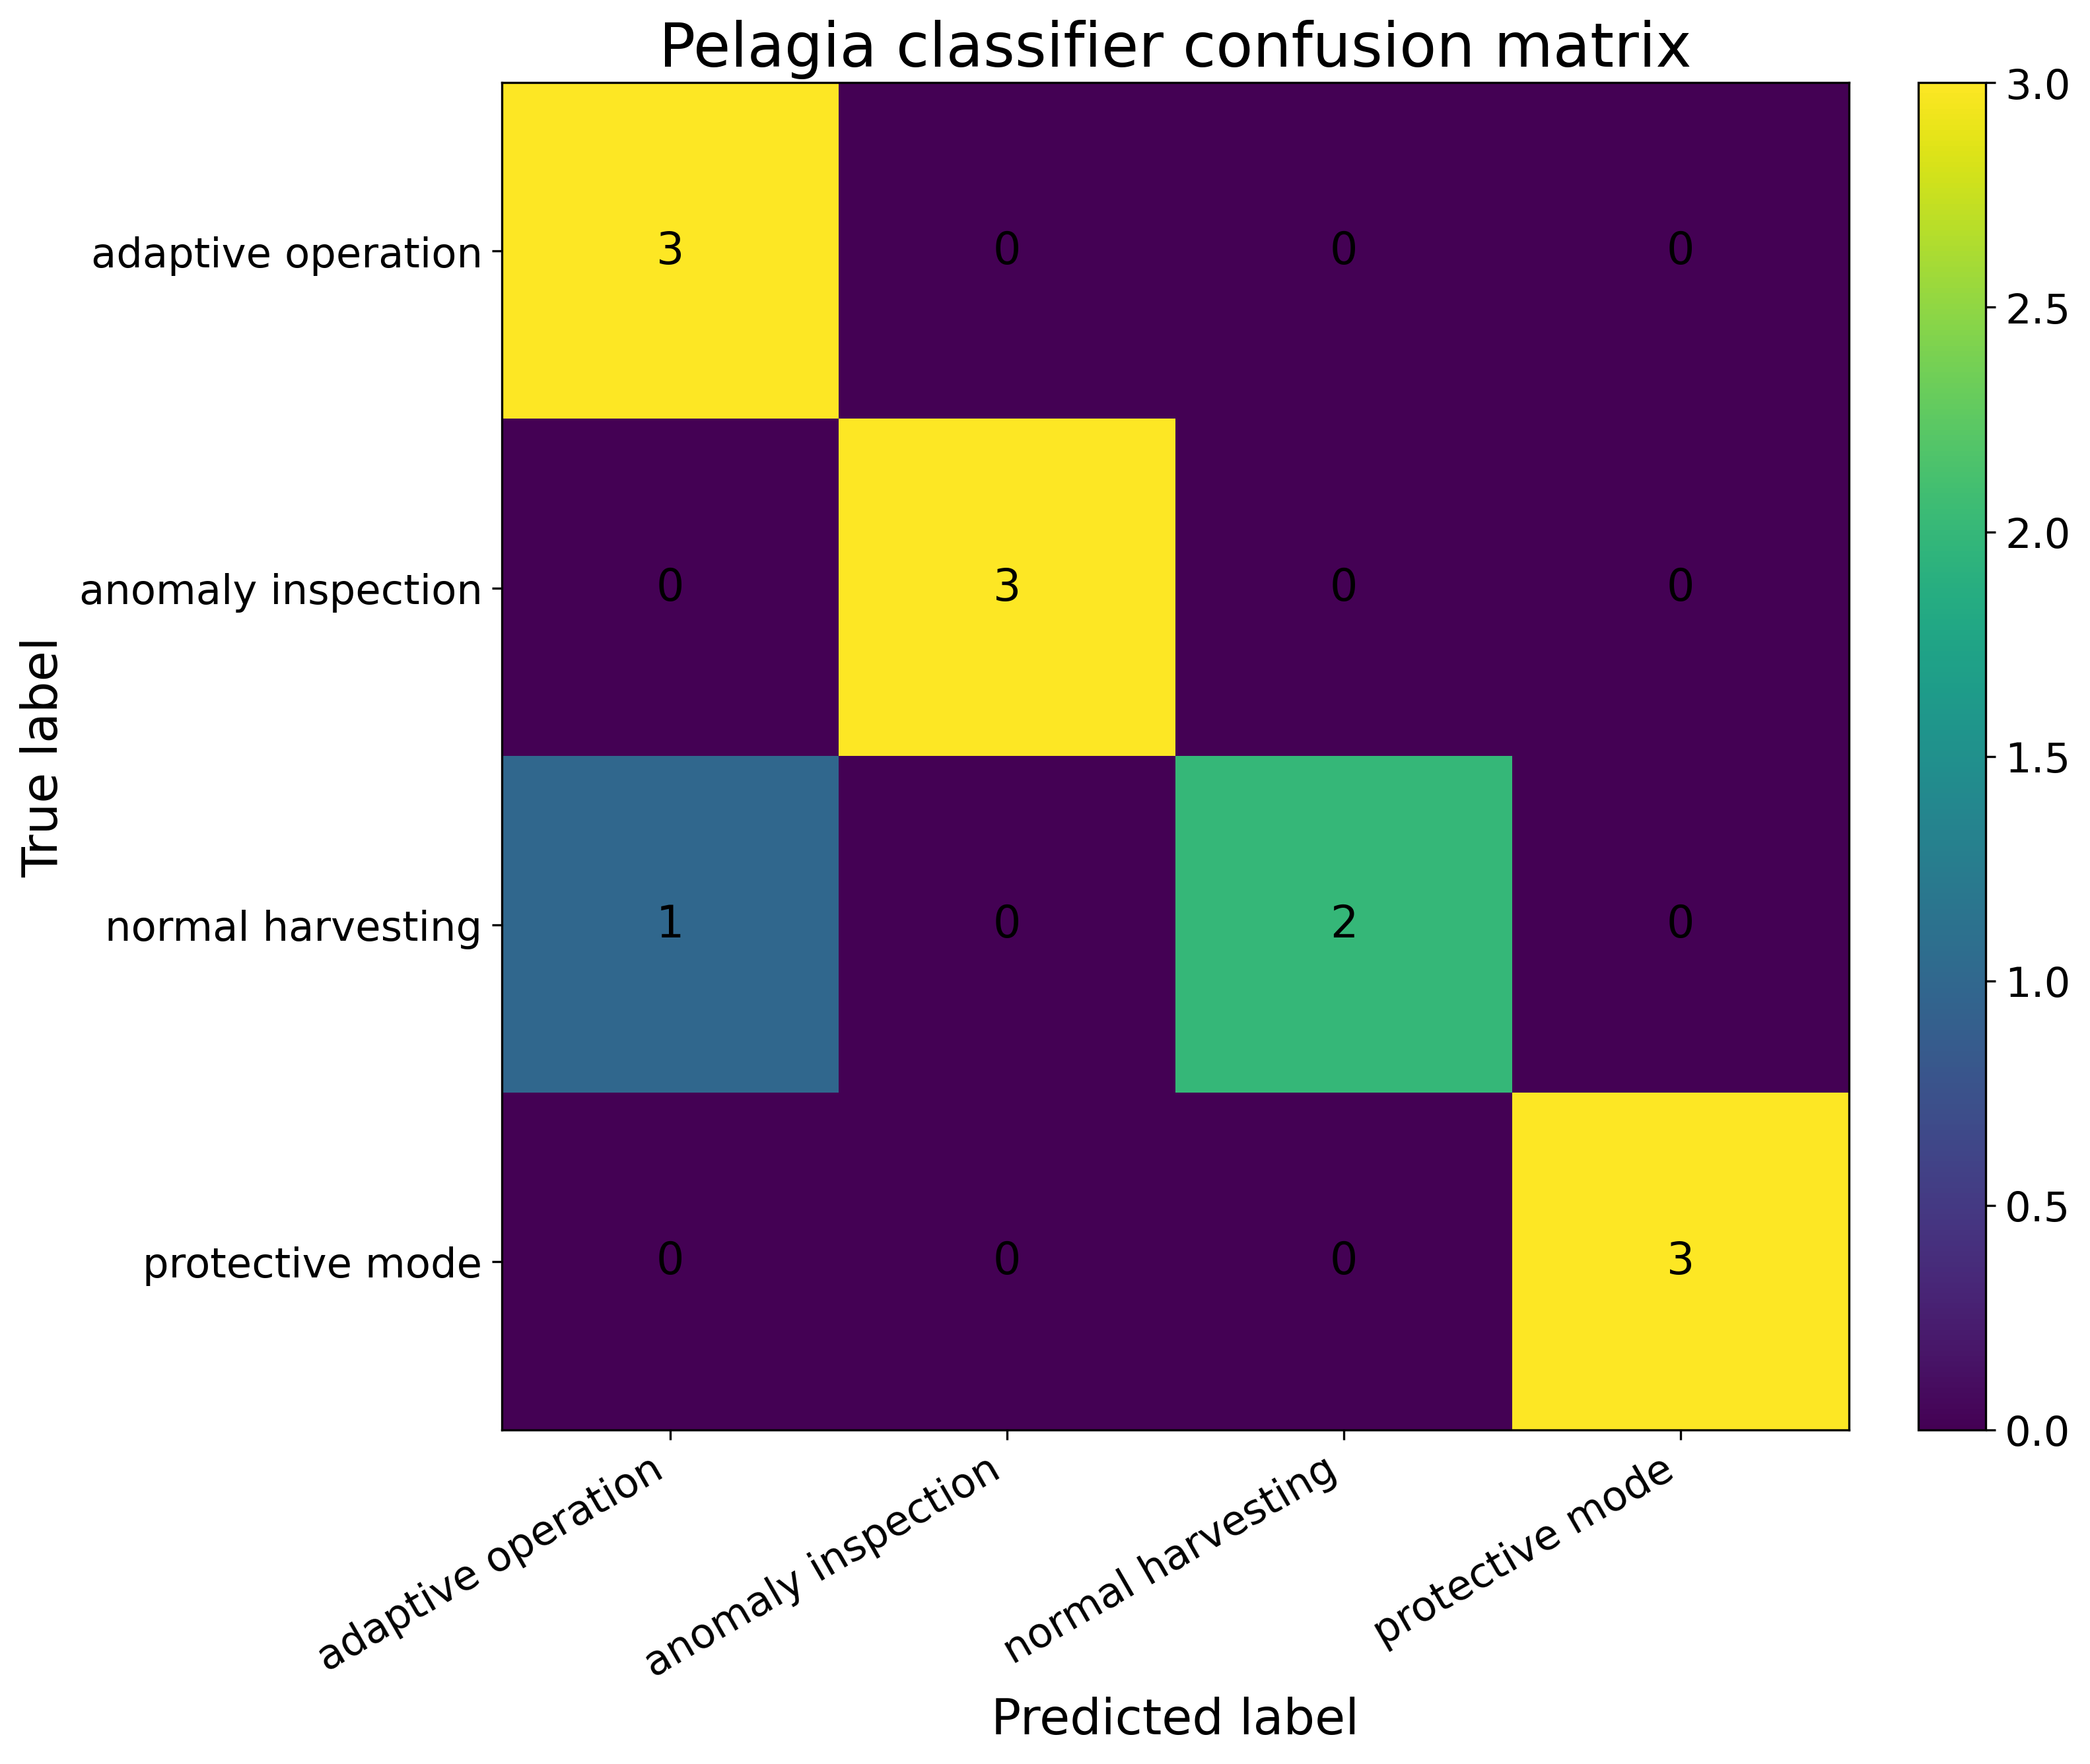

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/Pelagia1/figures/pelagia_confusion_matrix.png"))

In [ ]:
import shutil
from pathlib import Path
from google.colab import files

source_dir = Path("/content/Pelagia1/figures")
bundle_dir = Path("/content/pelagia_paper_plots")

if bundle_dir.exists():
    shutil.rmtree(bundle_dir)
bundle_dir.mkdir(parents=True, exist_ok=True)

for name in ["pelagia_decision_tree.png", "pelagia_confusion_matrix.png"]:
    src = source_dir / name
    if src.exists():
        shutil.copy(src, bundle_dir / name)
        print("Added:", name)
    else:
        print("Missing:", name)

zip_path = shutil.make_archive("/content/pelagia_paper_plots", "zip", bundle_dir)
print("Created:", zip_path)
files.download(zip_path)

Added: pelagia_decision_tree.png
Added: pelagia_confusion_matrix.png
Created: /content/pelagia_paper_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
%cd /content/Pelagia1

/content/Pelagia1


In [ ]:
import sys
src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [ ]:
from plot_branches import plot_decision_tree_figure

out_tree = plot_decision_tree_figure(fontsize=32)
print("Saved to:", out_tree)

Saved to: figures/pelagia_decision_tree.png


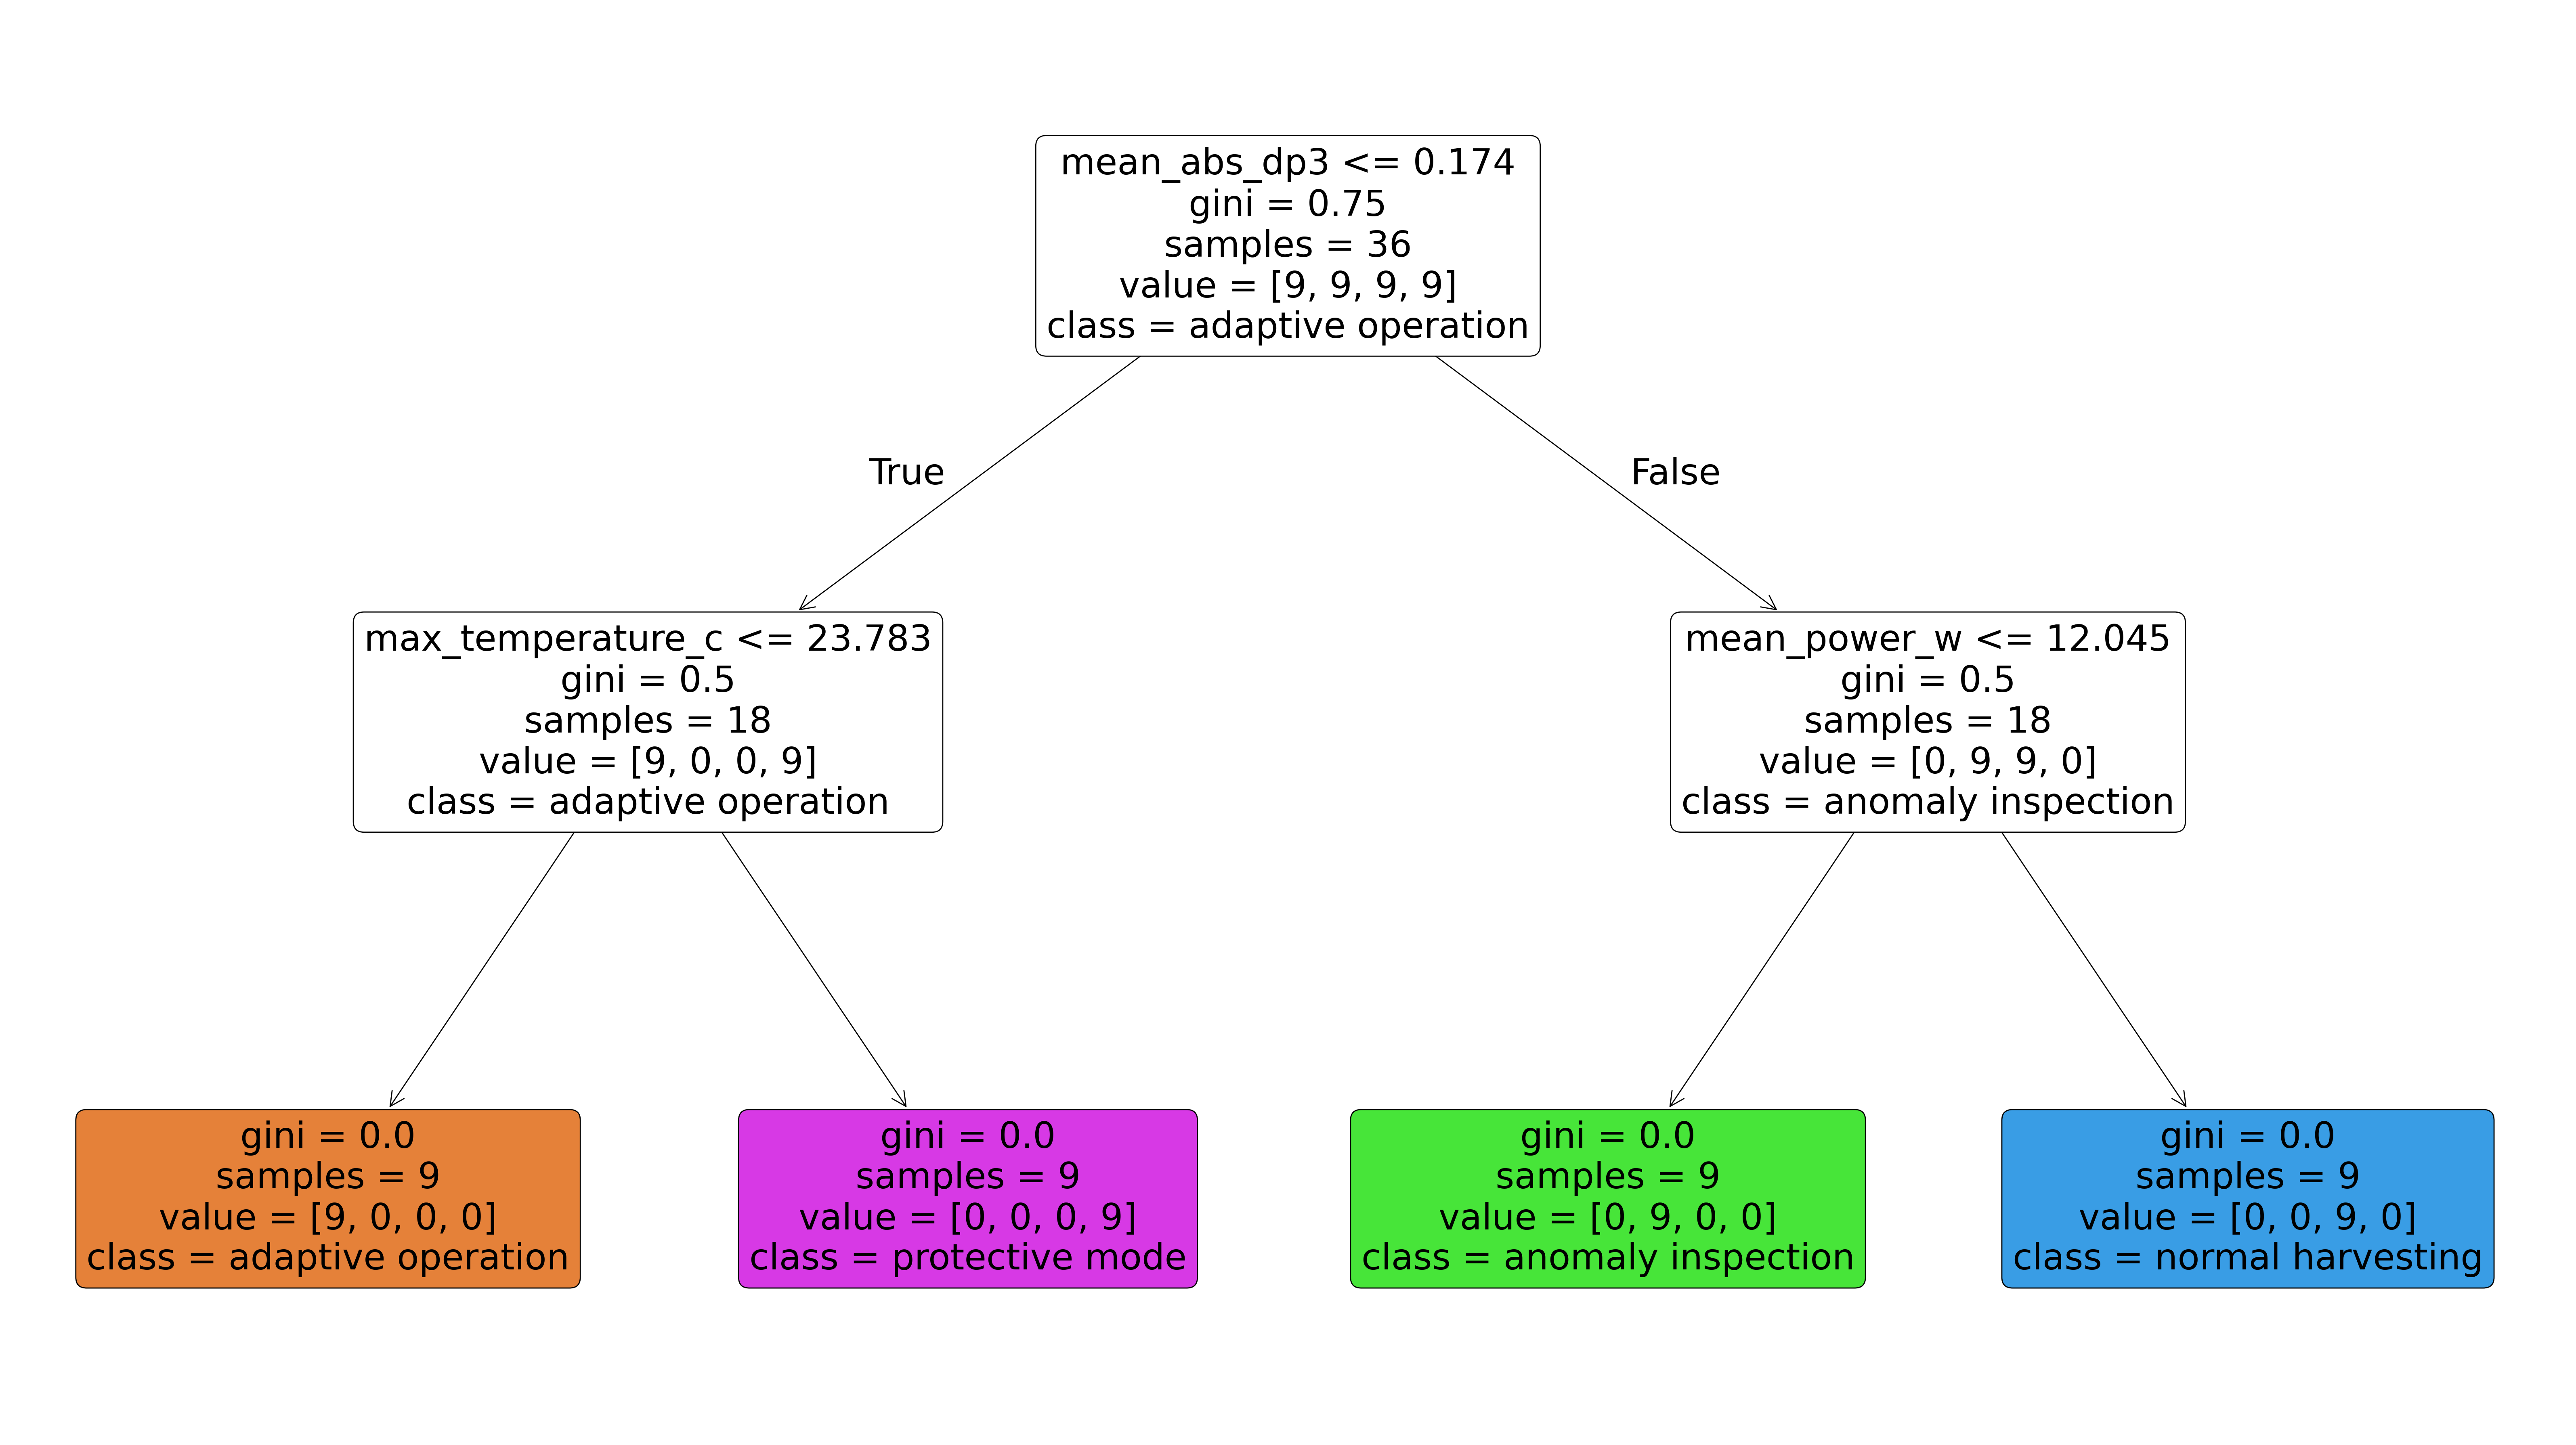

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(out_tree)))

In [ ]:
import shutil
from google.colab import files

src = "/content/Pelagia1/figures/pelagia_decision_tree.png"
dst = "/content/pelagia_decision_tree_font32.png"

shutil.copy(src, dst)
files.download(dst)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>